# Predicting Bike Rentals

<i><b>What the project is about.</b></i>
<br>    Many U.S. cities have communal bike sharing stations where you can rent bicycles by the hour or day. Washington, D.C. is one of these cities. The District collects detailed data on the number of bicycles people rent by the hour and day.


<i><b>What the goal is in this project.</b></i>
<br>In this project, I'll show how to predict the total number of bikes people rented in a given hour.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Understanding the Data

<br>    The file contains 17380 rows, with each row representing the number of bike rentals for a single hour of a single day.
<br>    You can download the data from the [University of California, Irvine's website](http://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset).

In [3]:
bike_rentals = pd.read_csv('bike_rental_hour.csv')
bike_rentals.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Some info about features:
- instant: record index
- dteday : date
- season : season (1:winter, 2:spring, 3:summer, 4:fall)
- yr : year (0: 2011, 1:2012)
- mnth : month ( 1 to 12)
- hr : hour (0 to 23)
- holiday : weather day is holiday or not (extracted from [Web Link])
- weekday : day of the week
- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
- weathersit :
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
- atemp: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
- hum: Normalized humidity. The values are divided to 100 (max)
- windspeed: Normalized wind speed. The values are divided to 67 (max)
- casual: count of casual users
- registered: count of registered users

Let's have a look into 'cnt' feature. It shows count of total rental bikes including both casual and registered. And find correlation to other features.

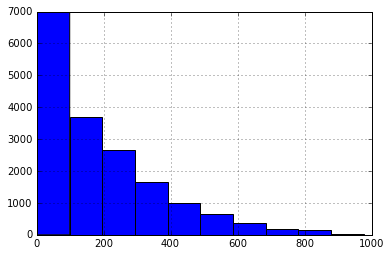

In [6]:
%matplotlib inline
bike_rentals['cnt'].hist()

In [17]:
bike_rentals.corr()['cnt'].sort_values(ascending=True)

hum          -0.322911
weathersit   -0.142426
holiday      -0.030927
weekday       0.026900
workingday    0.030284
windspeed     0.093234
mnth          0.120638
season        0.178056
yr            0.250495
instant       0.278379
hr            0.394071
atemp         0.400929
temp          0.404772
casual        0.694564
registered    0.972151
cnt           1.000000
Name: cnt, dtype: float64

It looks like count of total rental bikes would be most affected by weather conditions and time. Let's explore hr feature to see whether it would be useful.

### Feature Engineering

The hr column in bike_rentals contains the hours during which bikes are rented, from 1 to 24. A machine treats each hour differently, without understanding that certain hours are related. 

We can introduce some order into the process by creating a new column with labels for morning, afternoon, evening, and night. This bundles similar times together, enabling the model to make better decisions.

In [20]:
def assign_label(hr_value):
    if (hr_value > 6) and (hr_value <= 12):
        return 1
    elif (hr_value > 12) and (hr_value <= 18):
        return 2
    elif (hr_value > 18) and (hr_value <= 24):
        return 3
    elif (hr_value >= 0) and (hr_value <= 6):
        return 4
    
bike_rentals['time_label'] = bike_rentals['hr'].apply(assign_label)
bike_rentals.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,time_label
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,4
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,4
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,4
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,4
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,4


###  Splitting the Data Into Train and Test Sets

In [21]:
train = bike_rentals.sample(frac=.8)

In [22]:
test = bike_rentals.loc[~bike_rentals.index.isin(train.index)]

### Error metric

The mean squared error metric makes the most sense to evaluate our error. MSE works on continuous numeric data, which fits our data quite well.

### Applying Linear Regression

Linear regression works best when predictors are linearly correlated to the target and also independent -- in other words, they don't change meaning when we combine them with each other. 

The good thing about linear regression is that it's fairly resistant to overfitting because it's straightforward. It also can be prone to underfitting the data, however, and not building a powerful enough model. This means that linear regression usually isn't the most accurate option.

In [24]:
columns = ['instant', 'season', 'yr', 'mnth', 'hr', 
           'holiday', 'weekday', 'workingday', 
           'weathersit', 'temp', 'atemp', 'hum', 
           'windspeed', 'time_label']

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr = LinearRegression()
lr.fit(train[columns], train['cnt'])

y_pred = lr.predict(test[columns])

MSE = mean_squared_error(test['cnt'], y_pred)
print('MSE for LinearRegression: ', MSE)

MSE for LinearRegression:  16009.40429514987


The error is very high, which may be due to the fact that the data has a few extremely high rental counts but otherwise mostly low counts. Larger errors are penalized more with MSE, which leads to a higher total error.

### Applying Decision Trees

Decision trees tend to predict outcomes much more reliably than linear regression models, because a decision tree is a fairly complex model, it also tends to overfit, particularly when we don't tweak parameters like maximum depth and minimum number of samples per leaf. 
Decision trees are also prone to instability -- small changes in the input data can result in a very different output model.

In [40]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(min_samples_leaf=10)
dt.fit(train[columns], train['cnt'])

print('MSE for Decision Tree: ', mean_squared_error(test['cnt'], 
                                                       dt.predict(test[columns])))


MSE for Decision Tree:  2863.091924538515


By taking the nonlinear predictors into account, the decision tree regressor appears to have much higher accuracy than linear regression.

###  Applying Random Forests

Random forests tend to be much more accurate than simple models like linear regression. Due to the way random forests are constructed, they tend to overfit much less than decision trees. Random forests are prone to overfitting, so it's important to tune parameters like maximum depth and minimum samples per leaf.

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(min_samples_leaf=2)
rf.fit(train[columns], train['cnt'])

print('MSE for Random Forest: ', mean_squared_error(test['cnt'], 
                                                       rf.predict(test[columns])))


MSE for Random Forest:  2080.447306819906


By removing some of the sources of overfitting, the random forest accuracy is improved over the decision tree accuracy.

### Conclusion

I've showed some basic data science workflow for simple problem that included:
- understanding data, 
- finding correlation,
- engineering features,
- splitting dataset for training and testing,
- choosing metric to optimize,
- applying linear and non-linear machine learning algorithms,
- evaluating models performance on unseen data.

As next steps good idea would be to look into features related to weather condition, such as temperature, humidity, and wind speed.